In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
account_transactions = pd.read_csv(r"E:\Retail Banking\data\account_transactions.csv")
bank_accounts = pd.read_csv(r"E:\Retail Banking\data\bank_accounts.csv")
customer_profiles = pd.read_csv(r"E:\Retail Banking\data\customer_profiles.csv")
transaction_codes = pd.read_csv(r"E:\Retail Banking\data\transaction_codes.csv")

### Step 1: Check Data Type

In [3]:
for name, df in {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print(df.info())


ACCOUNT_TRANSACTIONS
Shape: (2377169, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2377169 entries, 0 to 2377168
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   transaction_id         str    
 1   account_id             str    
 2   linked_transaction_id  str    
 3   created_time           str    
 4   transaction_type       str    
 5   transaction_code       str    
 6   amount                 float64
 7   channel                str    
dtypes: float64(1), str(7)
memory usage: 401.7 MB
None

BANK_ACCOUNTS
Shape: (3553, 9)
<class 'pandas.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   account_id      3553 non-null   str    
 1   customer_id     3553 non-null   str    
 2   account_type    3553 non-null   str    
 3   creation_date   3553 non-null   str    
 4   account_status  3553 non-null   str    


### Step 2: Summary Statistics

In [4]:
for name, df in {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}.items():
    print(f"\n{name.upper()}")
    print(df.describe().round())
    


ACCOUNT_TRANSACTIONS
          amount
count  2377169.0
mean       911.0
std       6560.0
min          0.0
25%         69.0
50%        200.0
75%        620.0
max    1214710.0

BANK_ACCOUNTS
         balance  loan_amount  term_months  interest_rate
count     3553.0       1007.0       2553.0         2553.0
mean     93478.0      76235.0         24.0            9.0
std     167400.0     142774.0         17.0            6.0
min          0.0       1058.0          3.0            0.0
25%          0.0      12471.0         12.0            4.0
50%      20678.0      22845.0         24.0            5.0
75%      93214.0      49899.0         36.0           13.0
max    1693797.0     798423.0         60.0           24.0

CUSTOMER_PROFILES
                                 customer_id  national_id  birth_date  \
count                                   1000         1000        1000   
unique                                  1000         1000         975   
top     dc3dd10b-91ed-4453-89bb-9f624c441030  UA88

### Step 3: Check Missing Values

In [5]:
for name, df in {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


ACCOUNT_TRANSACTIONS
transaction_id                 0
account_id                     0
linked_transaction_id    2340893
created_time                   0
transaction_type               0
transaction_code               0
amount                         0
channel                        0
dtype: int64

BANK_ACCOUNTS
account_id           0
customer_id          0
account_type         0
creation_date        0
account_status       0
balance              0
loan_amount       2546
term_months       1000
interest_rate     1000
dtype: int64

CUSTOMER_PROFILES
customer_id    0
national_id    0
birth_date     0
city           0
state          0
dtype: int64

TRANSACTION_CODES
transaction_code    0
label               0
account_type        0
transaction_type    0
channel             0
dtype: int64


### Step 4: Check Duplicate Values

In [6]:
for name, df in {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}.items():
    print(f"\n{name.upper()}")
    print(df[df.duplicated()])


ACCOUNT_TRANSACTIONS
Empty DataFrame
Columns: [transaction_id, account_id, linked_transaction_id, created_time, transaction_type, transaction_code, amount, channel]
Index: []

BANK_ACCOUNTS
Empty DataFrame
Columns: [account_id, customer_id, account_type, creation_date, account_status, balance, loan_amount, term_months, interest_rate]
Index: []

CUSTOMER_PROFILES
Empty DataFrame
Columns: [customer_id, national_id, birth_date, city, state]
Index: []

TRANSACTION_CODES
Empty DataFrame
Columns: [transaction_code, label, account_type, transaction_type, channel]
Index: []


### Step 5: Check Primary Key Record Duplicates

In [7]:
account_transactions['transaction_id'].value_counts()

transaction_id
f5526a0f-4ec2-4aa4-a01e-33034d40ec33    1
b1c5757f-587d-418b-9238-35c4e338b731    1
f248fe0e-b646-4df6-a9d8-e8ebcd386c92    1
44314720-e02d-4c39-8aaf-b0d81380225d    1
9dcabefa-fe70-4d3f-b29e-22c442cba3dd    1
                                       ..
12aa54d8-d143-490c-a7f0-d92f44692999    1
426529bc-9135-4407-ba60-c1a1472b007d    1
2382fa0f-997b-4cdd-b934-0564c8b6db6f    1
07d79e26-6a3b-4fdb-b311-c67a66a70610    1
59b14700-2a6f-49eb-a719-d5cb511649fa    1
Name: count, Length: 2377169, dtype: int64

In [8]:
account_transactions['account_id'].value_counts()

account_id
26ee441d-a4af-4caf-92f9-e72a8dc9525f    13073
5f770927-9772-4336-ba9a-806d8ddafccf    12651
006109e7-0e4a-4fb9-9b98-355faf3dc5be    11963
b2bbf698-a9a8-4951-b9fd-688dbbe74dc2    11911
659e8b1b-6ce1-45e4-93eb-e69307c03680    11326
                                        ...  
69670b65-e60c-4bcb-adf2-ade680e78281        1
6a014f98-2176-474f-85f9-113e74ca7ebd        1
79bff325-620c-426f-b679-be692b5ddd17        1
fbbc3630-2f62-4c71-bf7e-6d14e420f35c        1
7c7a4bbd-a30c-47f0-9cd3-b5d9f217e76f        1
Name: count, Length: 3553, dtype: int64

In [9]:
account_transactions['linked_transaction_id'].value_counts()

linked_transaction_id
54a494ab-7011-4ee5-9325-db3291e3e0bb    1
33216ebe-e500-425f-8d77-38fc8f6e2557    1
bf649c9e-e8f5-46c6-b11d-0b45e4eaf33d    1
03bc99f3-9dfd-4b2d-8225-d32211f812f2    1
f0333595-1b6a-47b0-8c31-1bb06e317de0    1
                                       ..
f0da2b1d-0d71-4ca5-877e-f080691d464a    1
dc4f0591-351c-47dc-b50a-e539586ff001    1
cd63e9c3-d5a4-4000-9310-da07c6997374    1
07d79e26-6a3b-4fdb-b311-c67a66a70610    1
2382fa0f-997b-4cdd-b934-0564c8b6db6f    1
Name: count, Length: 36276, dtype: int64

In [10]:
bank_accounts['account_id'].value_counts()

account_id
eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea    1
bb9837da-5ee5-4d30-9c22-b2d6e2fffafa    1
2ab94e36-bff3-45e8-8db7-966075a889d6    1
0aeb7e68-88cc-4167-94af-fee48a795ba0    1
6bbcc4b6-2456-45f5-b87b-77ef1356e1e2    1
                                       ..
1bf36a76-595d-4069-a1ed-a9b83d706fe7    1
589ce304-583f-4c22-96b6-8b12eb62759f    1
3bbb0753-aabb-4112-8a9b-9004d718715f    1
ba22681b-c02e-4d19-8bae-7c6a9d78f0d5    1
40272448-f7fd-41fa-9049-77a4641b40f7    1
Name: count, Length: 3553, dtype: int64

In [11]:
bank_accounts['customer_id'].value_counts()

customer_id
33526715-6f38-4560-9cec-2faddb2e18cc    6
711d1a09-2c23-47cd-906d-36f21485d178    6
7d4858da-05d8-4db2-9cda-aaef3401ed6f    6
ed154512-8b23-4841-802b-eddf6d91f2b0    6
a2df4517-6bd6-462a-9833-5662008bba5f    6
                                       ..
50cb4259-2e6f-49a3-b219-d4a6f4657b10    1
406c8c17-79f4-48c1-8435-1bc8ac94c50d    1
cdc31bba-d294-4771-b61f-65392bb8250b    1
c1da5870-713f-4bd3-b0f3-4105738a39dc    1
eaaddcf2-b74f-4b22-892b-3faa4353fab0    1
Name: count, Length: 1000, dtype: int64

In [12]:
customer_profiles['customer_id'].value_counts()

customer_id
dc3dd10b-91ed-4453-89bb-9f624c441030    1
d8946376-be1f-48cc-a278-f8b3b967cd77    1
83fae1e1-7a78-42d4-81fd-803ebdeedb2d    1
24405b2f-c105-4f3f-9aaf-8bc07f4cae9f    1
3869d8bc-f40c-4f5e-a283-6137c3c35e49    1
                                       ..
d4c69b6d-71da-4430-aaab-2f9e5d43c5c7    1
17eb1d93-e605-48bc-ae6d-c7e1769e79ce    1
eaaddcf2-b74f-4b22-892b-3faa4353fab0    1
14dfa847-bf2b-4911-8c22-6e66b441cbe9    1
3bdeeed7-e36d-4dd8-9869-39017e83328f    1
Name: count, Length: 1000, dtype: int64

In [13]:
customer_profiles['national_id'].value_counts()

national_id
UA886206902    1
IB516472288    1
CS768525777    1
RX998412214    1
DT348481917    1
              ..
ZW625334698    1
ZP467386881    1
EK040620569    1
UA438450741    1
LB226074847    1
Name: count, Length: 1000, dtype: int64

### Step 6: Check Categorical Data

In [14]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
for name, df in datasets.items():
    print(f"\nDataset: {name}")
    print('-'*30)

    for col in df.columns:
        if df[col].dtype == 'str' and df[col].nunique() >= 2:
            print(df[col].value_counts())
            print('-'*50)




Dataset: account_transactions
------------------------------
transaction_id
f5526a0f-4ec2-4aa4-a01e-33034d40ec33    1
b1c5757f-587d-418b-9238-35c4e338b731    1
f248fe0e-b646-4df6-a9d8-e8ebcd386c92    1
44314720-e02d-4c39-8aaf-b0d81380225d    1
9dcabefa-fe70-4d3f-b29e-22c442cba3dd    1
                                       ..
12aa54d8-d143-490c-a7f0-d92f44692999    1
426529bc-9135-4407-ba60-c1a1472b007d    1
2382fa0f-997b-4cdd-b934-0564c8b6db6f    1
07d79e26-6a3b-4fdb-b311-c67a66a70610    1
59b14700-2a6f-49eb-a719-d5cb511649fa    1
Name: count, Length: 2377169, dtype: int64
--------------------------------------------------
account_id
26ee441d-a4af-4caf-92f9-e72a8dc9525f    13073
5f770927-9772-4336-ba9a-806d8ddafccf    12651
006109e7-0e4a-4fb9-9b98-355faf3dc5be    11963
b2bbf698-a9a8-4951-b9fd-688dbbe74dc2    11911
659e8b1b-6ce1-45e4-93eb-e69307c03680    11326
                                        ...  
69670b65-e60c-4bcb-adf2-ade680e78281        1
6a014f98-2176-474f-85f9-113e74ca7e

## Data Cleaning

### Handling Missing Data

In [15]:
account_transactions['linked_transaction_id'].notna().sum()

np.int64(36276)

In [16]:
account_transactions[account_transactions['linked_transaction_id'].notna()].head(10)

,transaction_id,account_id,linked_transaction_id,created_time,transaction_type,transaction_code,amount,channel
800,33216ebe-e500-425f-8d77-38fc8f6e2557,bb9837da-5ee5-4d30-9c22-b2d6e2fffafa,54a494ab-7011-4ee5-9325-db3291e3e0bb,2024-05-27 19:48:00,Credit,LN_DISB,599649.18,Branch
801,54a494ab-7011-4ee5-9325-db3291e3e0bb,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,33216ebe-e500-425f-8d77-38fc8f6e2557,2024-05-27 19:48:00,Credit,LN_DISB_CR,599649.18,Branch
856,03bc99f3-9dfd-4b2d-8225-d32211f812f2,bb9837da-5ee5-4d30-9c22-b2d6e2fffafa,bf649c9e-e8f5-46c6-b11d-0b45e4eaf33d,2024-06-26 13:27:00,Debit,LN_PMNT,16656.92,Branch
857,bf649c9e-e8f5-46c6-b11d-0b45e4eaf33d,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,03bc99f3-9dfd-4b2d-8225-d32211f812f2,2024-06-26 13:27:00,Debit,LN_PMNT_DR,16656.92,Branch
920,651a2292-0721-4542-8778-39ac04ac8614,bb9837da-5ee5-4d30-9c22-b2d6e2fffafa,f0333595-1b6a-47b0-8c31-1bb06e317de0,2024-07-26 13:55:00,Debit,LN_PMNT,16656.92,Branch
921,f0333595-1b6a-47b0-8c31-1bb06e317de0,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,651a2292-0721-4542-8778-39ac04ac8614,2024-07-26 13:55:00,Debit,LN_PMNT_DR,16656.92,Branch
979,b69d934a-0dcf-4f9a-8780-15a50fdf02a4,bb9837da-5ee5-4d30-9c22-b2d6e2fffafa,a1857ec3-c7bd-4bf3-af43-091a2feefae7,2024-08-25 11:16:00,Debit,LN_PMNT,16656.92,Branch
980,a1857ec3-c7bd-4bf3-af43-091a2feefae7,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,b69d934a-0dcf-4f9a-8780-15a50fdf02a4,2024-08-25 11:16:00,Debit,LN_PMNT_DR,16656.92,Branch
1047,2627c82d-a649-4dd8-bf98-40493c3e1afc,bb9837da-5ee5-4d30-9c22-b2d6e2fffafa,065d47ea-7f5b-4e0c-ae34-b640eb294bfd,2024-09-24 17:31:00,Debit,LN_PMNT,16656.92,Branch
1048,065d47ea-7f5b-4e0c-ae34-b640eb294bfd,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,2627c82d-a649-4dd8-bf98-40493c3e1afc,2024-09-24 17:31:00,Debit,LN_PMNT_DR,16656.92,Branch


In [18]:
account_transactions[account_transactions['linked_transaction_id'].notna()].shape

(36276, 8)

In [19]:
linked_data = account_transactions['linked_transaction_id'].dropna()
linked_data.isin(account_transactions['transaction_id']).sum()

np.int64(36276)

In [22]:
bank_accounts.groupby('account_type')[['loan_amount', 'term_months', 'interest_rate']].agg(['count', 'mean'])

loan_amount               term_months            interest_rate  \
                   count          mean       count       mean         count   
account_type                                                                  
FixedDeposit           0           NaN        1546  16.090556          1546   
Loan                1007  76234.810278        1007  35.153923          1007   
Savings                0           NaN           0        NaN             0   

                         
                   mean  
account_type             
FixedDeposit   4.240944  
Loan          15.558093  
Savings             NaN

### Check Inconsistent Formating

In [24]:
account_transactions['transaction_type'].unique()

<ArrowStringArray>
['Credit', 'Debit']
Length: 2, dtype: str

In [25]:
account_transactions['transaction_code'].unique()

<ArrowStringArray>
[    'IBK_IN',    'CSH_WDL',    'MER_PAY',    'IBK_OUT',    'CSH_DEP',
    'SYS_FEE',    'LN_DISB', 'LN_DISB_CR',    'LN_PMNT', 'LN_PMNT_DR',
 'LN_INT_CHG',    'FD_OPEN', 'FD_OPEN_DR', 'FD_MAT_CHG',  'FD_MAT_CR']
Length: 15, dtype: str

In [26]:
account_transactions['channel'].unique()

<ArrowStringArray>
['InterbankPortal', 'Branch', 'MobileApp', 'OnlineBanking', 'ATM', 'System']
Length: 6, dtype: str

In [28]:
bank_accounts['account_type'].unique()

<ArrowStringArray>
['Savings', 'Loan', 'FixedDeposit']
Length: 3, dtype: str

In [29]:
bank_accounts['account_status'].unique()

<ArrowStringArray>
['Active', 'Inactive']
Length: 2, dtype: str

In [31]:
customer_profiles['city'].unique()

<ArrowStringArray>
[         'Houston',     'Grand Rapids',       'Naperville',
           'Austin',        'Las Vegas',         'Bellevue',
          'Spokane',    'San Francisco',            'Miami',
          'Orlando',        'Allentown',    'New York City',
         'Syracuse',         'Columbus',        'Cleveland',
          'Gresham',        'Vancouver',      'Los Angeles',
    'Winston-Salem',       'Cincinnati',            'Tampa',
        'Worcester',             'Erie',       'Sacramento',
        'San Diego',       'Fort Worth',           'Tacoma',
       'Scottsdale',           'Sparks',        'Rochester',
           'Boston',        'Nashville',          'Detroit',
       'Evansville',           'Dallas',         'Rockford',
      'San Antonio',          'Memphis',           'Warren',
            'Akron',           'Albany',        'Milwaukee',
        'Hillsboro',         'San Jose',          'Reading',
           'Joliet',           'Durham',           'Aurora',
     

In [32]:
customer_profiles['state'].unique()

<ArrowStringArray>
[         'Texas',       'Michigan',       'Illinois',         'Nevada',
     'Washington',     'California',        'Florida',   'Pennsylvania',
       'New York',        'Georgia',           'Ohio',         'Oregon',
 'North Carolina',  'Massachusetts',        'Arizona',      'Tennessee',
        'Indiana',      'Wisconsin',       'Colorado',       'Virginia']
Length: 20, dtype: str

In [34]:
customer_profiles.groupby('city')['state'].unique().loc[lambda x : x.apply(len) > 1]

city
Aurora      [Illinois, Colorado]
Columbus         [Georgia, Ohio]
Name: state, dtype: object

### Correcting Data Types

In [36]:
account_transactions['created_time'] = pd.to_datetime(account_transactions['created_time'])

In [42]:
bank_accounts['creation_date'] = pd.to_datetime(bank_accounts['creation_date'])

In [47]:
bank_accounts['term_months'] = bank_accounts['term_months'].astype('Int64')

In [50]:
customer_profiles['birth_date'] = pd.to_datetime(customer_profiles['birth_date'])

### Handling Outliers

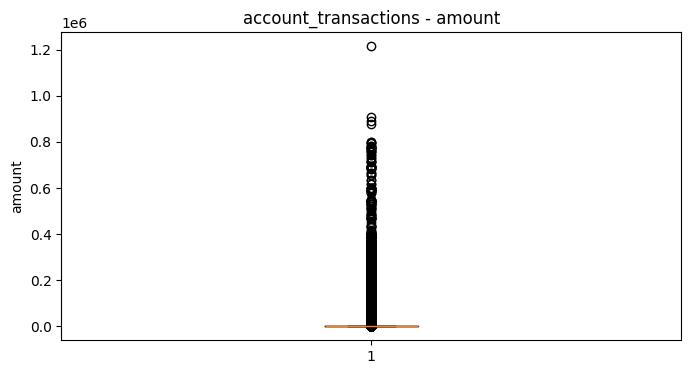

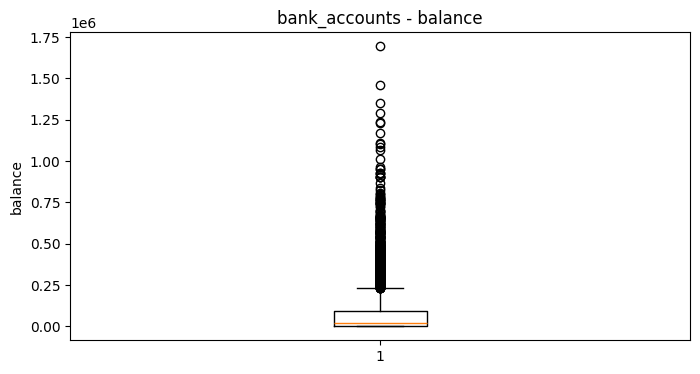

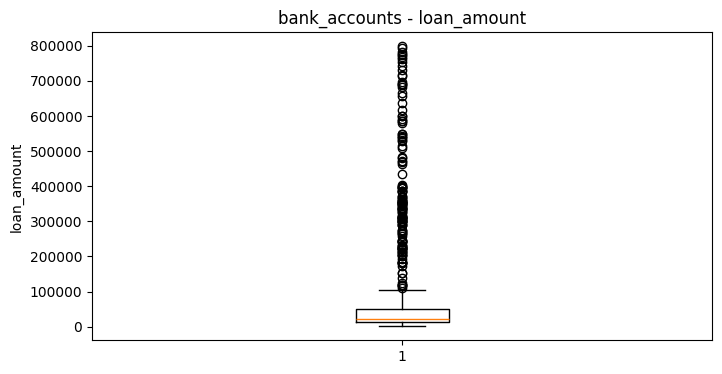

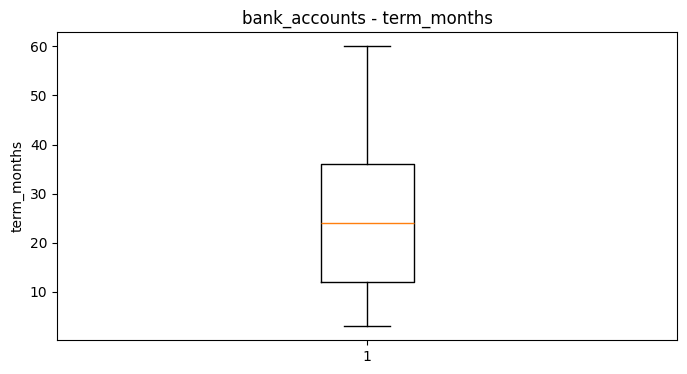

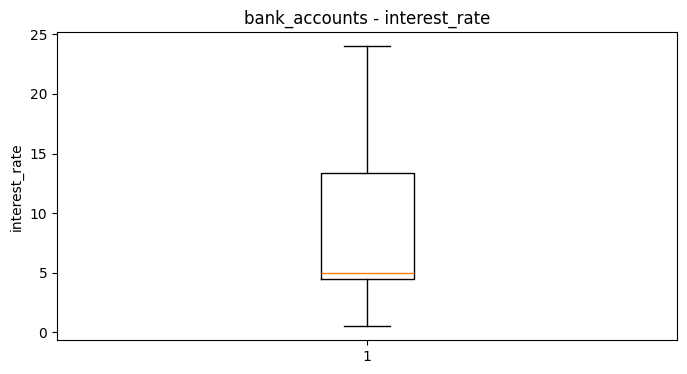

In [54]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
for name, df in datasets.items():
    numeric_columns = df.select_dtypes(include = np.number).columns

    for col in numeric_columns:
        plt.figure(figsize=(8, 4))
        plt.boxplot(df[col].dropna())
        plt.title(f'{name} - {col}')
        plt.ylabel(col)
        plt.show()

In [ ]:
numeric_cols = account_transactions.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = account_transactions[col].quantile(0.25)
    Q3 = account_transactions[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = account_transactions[(account_transactions[col] < lower) | (account_transactions[col] > upper)]

    print(f'{col}: {len(outliers)} outliers')

amount: 280704 outliers


In [59]:
numeric_cols = bank_accounts.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = bank_accounts[col].quantile(0.25)
    Q3 = bank_accounts[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = bank_accounts[(bank_accounts[col] < lower) | (bank_accounts[col] > upper)]

    print(f'{col}: {len(outliers)} outliers')

balance: 501 outliers
loan_amount: 143 outliers
term_months: 0 outliers
interest_rate: 0 outliers


In [61]:
account_transactions['amount'].describe().round()

count    2377169.0
mean         911.0
std         6560.0
min            0.0
25%           69.0
50%          200.0
75%          620.0
max      1214710.0
Name: amount, dtype: float64

In [62]:
datasets = {
    'account_transactions' : account_transactions,
    'bank_accounts' : bank_accounts,
    'customer_profiles' : customer_profiles,
    'transaction_codes' : transaction_codes
}
for name, df in datasets.items():
    df.to_csv(f'E:\Retail Banking\cleaned_data\{name}_Cleaned.csv', index=False)

<string>:8: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:8: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<string>:8: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:8: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\HAMAAD NASIR\AppData\Local\Temp\ipykernel_16176\2162442740.py